In [2]:
pip install torch torchvision

In [3]:
import torch

print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.11.0+cu128
CUDA available: True
Tesla T4


In [4]:
#Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

dataset_path = "/content/drive/MyDrive/Deep Learning/chest_xray/chest_xray"

print(os.listdir(dataset_path))

['.DS_Store', 'test', 'train', 'val']


In [6]:
from torchvision import datasets, transforms

In [7]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

val_test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [8]:
train_dataset = datasets.ImageFolder(
    root=dataset_path + "/train",
    transform=transform
)

In [9]:
print(train_dataset.classes)
print(len(train_dataset))

['NORMAL', 'PNEUMONIA']
5216


In [10]:
img, label = train_dataset[0]

print(type(img))
print(img.shape)
print(label)

<class 'torch.Tensor'>
torch.Size([3, 224, 224])
0


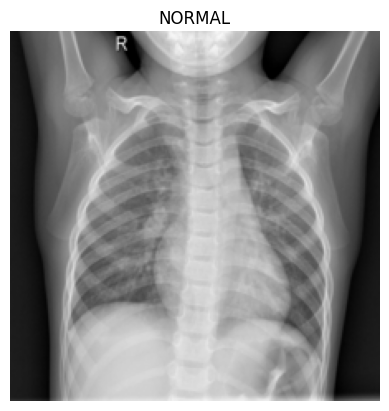

In [11]:
import matplotlib.pyplot as plt

img, label = train_dataset[0]

plt.imshow(img.permute(1, 2, 0))
plt.title(train_dataset.classes[label])
plt.axis('off')
plt.show()


In [12]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [13]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [14]:
from torchvision import models

model = models.resnet18(weights="DEFAULT")
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [15]:
import torch.nn as nn

model.fc = nn.Linear(
    in_features=512,
    out_features=2
)

print(model.fc)

Linear(in_features=512, out_features=2, bias=True)


In [16]:
device = torch.device("cuda")

model = model.to(device)

print(device)

cuda


In [17]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)


In [18]:
outputs = model(images)

print(outputs.shape)

torch.Size([32, 2])


In [19]:
print(outputs[:5])

tensor([[ 0.2981, -0.0650],
        [ 0.6284, -0.8691],
        [ 0.3950,  0.1851],
        [ 0.5691, -0.3979],
        [ 0.1169, -0.6559]], device='cuda:0', grad_fn=<SliceBackward0>)


In [20]:
predictions = torch.argmax(outputs, dim=1)

print(predictions[:10])
print(labels[:10])

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')
tensor([1, 1, 1, 0, 1, 1, 0, 1, 1, 1], device='cuda:0')


In [21]:
criterion = nn.CrossEntropyLoss()

In [22]:
loss = criterion(outputs, labels)

print(loss)

tensor(0.9026, device='cuda:0', grad_fn=<NllLossBackward0>)


In [23]:
import torch.optim as optim

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [24]:
optimizer.zero_grad()

In [25]:
loss.backward()

In [26]:
optimizer.step()

In [27]:
val_dataset = datasets.ImageFolder(
    root=dataset_path + "/val",
    transform=transform
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print(len(val_dataset))

16


In [28]:
print(val_dataset.classes)
print(len(val_dataset))

['NORMAL', 'PNEUMONIA']
16


In [29]:
print(next(model.parameters()).device)

cuda:0


In [30]:
running_loss = 0

model.train()

for batch_idx, (images, labels) in enumerate(train_loader):

    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)

    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    running_loss += loss.item()

    if batch_idx % 20 == 0:
        print(f"Batch {batch_idx}/{len(train_loader)}")

print("Average Loss:", running_loss / len(train_loader))


Batch 0/163
Batch 20/163
Batch 40/163
Batch 60/163
Batch 80/163
Batch 100/163
Batch 120/163
Batch 140/163
Batch 160/163
Average Loss: 0.120524112893657


In [31]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        total += labels.size(0)

        correct += (predictions == labels).sum().item()

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 50.00%


In [32]:
test_dataset = datasets.ImageFolder(
    root=dataset_path + "/test",
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print(len(test_dataset))

624


In [33]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 66.19%


In [34]:
train_dataset = datasets.ImageFolder(
    root=dataset_path + "/train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=dataset_path + "/val",
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    root=dataset_path + "/test",
    transform=val_test_transform
)

In [35]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [36]:
from torchvision import models
import torch.nn as nn

model = models.resnet18(weights="DEFAULT")

model.fc = nn.Linear(
    model.fc.in_features,
    2
)

model = model.to(device)

In [37]:
num_epochs = 10

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{num_epochs}, "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )

Epoch 1/10, Loss: 0.7231
Epoch 2/10, Loss: 0.7274
Epoch 3/10, Loss: 0.7268
Epoch 4/10, Loss: 0.7225
Epoch 5/10, Loss: 0.7258
Epoch 6/10, Loss: 0.7260
Epoch 7/10, Loss: 0.7284
Epoch 8/10, Loss: 0.7294
Epoch 9/10, Loss: 0.7236
Epoch 10/10, Loss: 0.7263


In [38]:
print(train_dataset.class_to_idx)

from collections import Counter

labels = [label for _, label in train_dataset.samples]
print(Counter(labels))

{'NORMAL': 0, 'PNEUMONIA': 1}
Counter({1: 3875, 0: 1341})


In [39]:
from sklearn.metrics import classification_report

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=test_dataset.classes
    )
)

              precision    recall  f1-score   support

      NORMAL       0.23      0.13      0.16       234
   PNEUMONIA       0.59      0.74      0.66       390

    accuracy                           0.51       624
   macro avg       0.41      0.44      0.41       624
weighted avg       0.45      0.51      0.47       624



In [40]:
torch.save(
    model.state_dict(),
    "pneumonia_detector.pth"
)

print("Model saved!")


Model saved!


In [1]:
import os
print(os.listdir())

['.config', 'sample_data']
